# Dipole antenna design diary

To begin designing our dipole, we'll target 2.4 GHz for Wi-Fi and Bluetooth. Our target wavelength is:

$$\lambda = \frac{c}{f} = \frac{299\,792\,458}{2.4\times10^9} \approx 0.1249\ \mathrm{m}$$

For a $\lambda/2$ dipole, this gives us 0.06245 m total, or 0.031225 m per arm.

In HFSS, we model the arms as cylinders with a 0.5 mm radius to account for wire size, with a 1 mm gap for the lumped port in the center. We set the port reference impedance to 50 Ω and tune the dipole for the best match to this impedance at 2.4 GHz.

The plots below use our HFSS CSV exports. We use `dL` for the total dipole length parameter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (8, 4), 'axes.grid': True, 'font.size': 11})

initial_s = np.loadtxt('s11_dipole_ideal.csv', delimiter=',', skiprows=1)
initial_z = np.loadtxt('z11_dipole_ideal.csv', delimiter=',', skiprows=1)
tuned_z = np.loadtxt('z11_dipole_tuned.csv', delimiter=',', skiprows=1)
sweep = np.loadtxt('s11_sweep_dipole_tuned.csv', delimiter=',', skiprows=1)
initial_gain = np.loadtxt('p_plane_gain_plot_dipole_ideal.csv', delimiter=',', skiprows=1)
tuned_gain = np.loadtxt('p_plane_gain_plot_dipole_tuned.csv', delimiter=',', skiprows=1)
directivity = np.loadtxt('3d_directivity_plot_dipole_ideal.csv', delimiter=',', skiprows=1)

## Initial radiation pattern

Checking the radiation pattern, we see the expected dipole shape, with maximum radiation broadside and nulls along the wire.

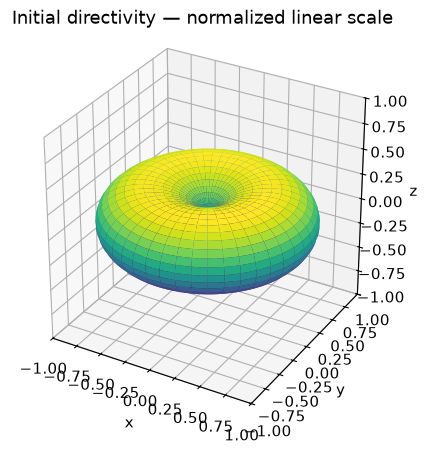

In [2]:
phi = np.deg2rad(np.unique(directivity[:, 0]))
theta = np.deg2rad(np.unique(directivity[:, 1]))
phi, theta = np.meshgrid(phi, theta)
order = np.lexsort((directivity[:, 0], directivity[:, 1]))
db = directivity[order, 2].reshape(theta.shape)
radius = 10 ** ((db - db.max()) / 10)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(radius * np.sin(theta) * np.cos(phi),
                radius * np.sin(theta) * np.sin(phi),
                radius * np.cos(theta), cmap='viridis', linewidth=0)
ax.set(xlabel='x', ylabel='y', zlabel='z', title='Initial directivity — normalized linear scale')
ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1))
ax.set_box_aspect((1, 1, 1))
plt.show()

## Initial analysis

Our first S11 minimum is at 2.184 GHz, around 2.2 GHz instead of the target 2.4 GHz. The finite wire radius and feed geometry shift the response from our half-wave estimate. At 2.4 GHz, S11 is only −6.74 dB.

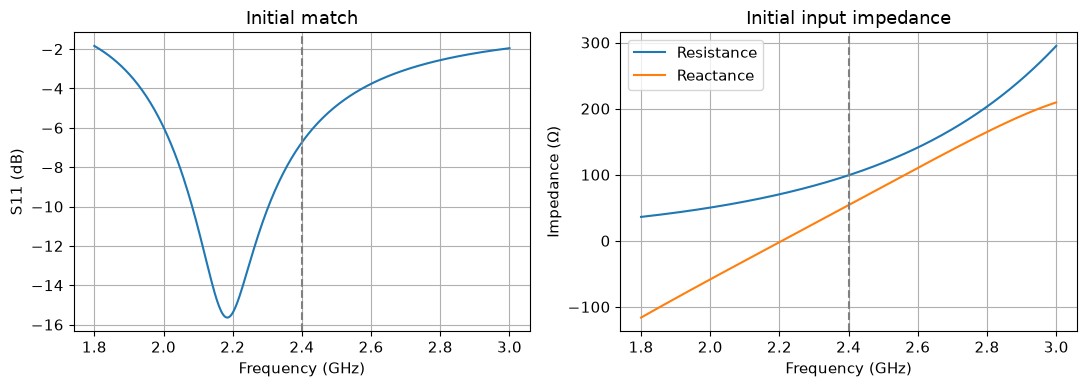

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(initial_s[:, 0], initial_s[:, 1])
axes[0].set(xlabel='Frequency (GHz)', ylabel='S11 (dB)', title='Initial match')
axes[1].plot(initial_z[:, 0], initial_z[:, 1], label='Resistance')
axes[1].plot(initial_z[:, 0], initial_z[:, 2], label='Reactance')
axes[1].set(xlabel='Frequency (GHz)', ylabel='Impedance (Ω)', title='Initial input impedance')
axes[1].legend()
for ax in axes:
    ax.axvline(2.4, color='gray', linestyle='--')
fig.tight_layout()
plt.show()

## Length sweep

To move the response up to 2.4 GHz, we shorten the dipole using a correction factor of about 0.91:

$$L \approx 0.06245\times0.91 = 0.05683\ \mathrm{m}$$

This gives us about 0.02842 m per arm. Instead of fixing this value, we sweep the arm length from 0.026 to 0.030 m with 10 steps to find the best match.

From that sweep, we narrow the total length to between 0.056666… and 0.057222 m, then fine-tune. The saved export below contains the fine sweep and the initial 0.0625 m reference.

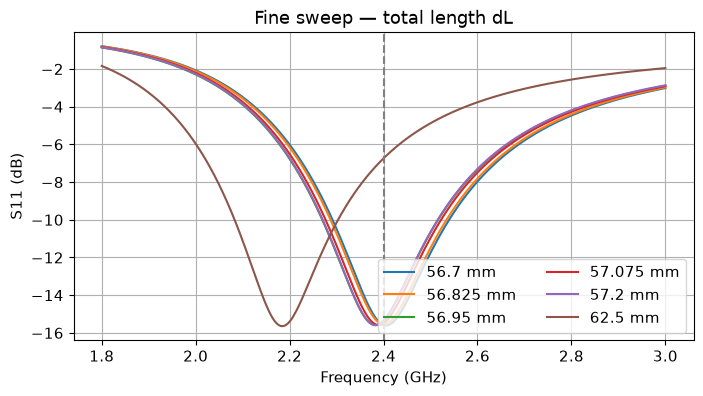

In [4]:
fig, ax = plt.subplots()
for length in np.unique(sweep[:, 0]):
    curve = sweep[np.isclose(sweep[:, 0], length)]
    ax.plot(curve[:, 1], curve[:, 2], label=f'{length * 1000:g} mm')
ax.axvline(2.4, color='gray', linestyle='--')
ax.set(xlabel='Frequency (GHz)', ylabel='S11 (dB)', title='Fine sweep — total length dL')
ax.legend(ncol=2)
plt.show()

## Final length

We select `dL = '0.056825'`, or 56.825 mm total. This puts the S11 minimum at 2.4 GHz, improving the match from −6.74 dB to −15.54 dB.

At 2.4 GHz, the input impedance is about $68.59 - j6.97\,\Omega$. The reactance crosses zero near 2.428 GHz, so the best match and resonance are slightly apart.

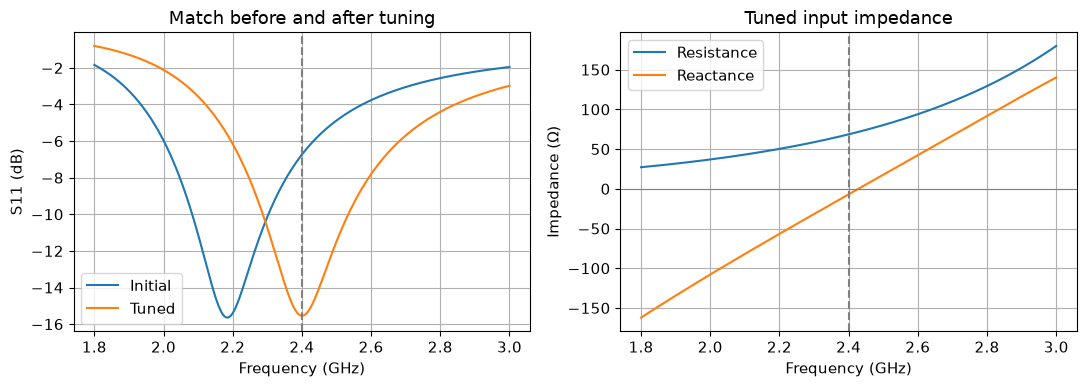

In [5]:
tuned_s = sweep[sweep[:, 0] == 0.056825]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(initial_s[:, 0], initial_s[:, 1], label='Initial')
axes[0].plot(tuned_s[:, 1], tuned_s[:, 2], label='Tuned')
axes[0].set(xlabel='Frequency (GHz)', ylabel='S11 (dB)', title='Match before and after tuning')
axes[1].plot(tuned_z[:, 1], tuned_z[:, 2], label='Resistance')
axes[1].plot(tuned_z[:, 1], tuned_z[:, 3], label='Reactance')
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set(xlabel='Frequency (GHz)', ylabel='Impedance (Ω)', title='Tuned input impedance')
for ax in axes:
    ax.axvline(2.4, color='gray', linestyle='--')
    ax.legend()
fig.tight_layout()
plt.show()

The Smith chart shows the change in matching, with dots marking 2.4 GHz.

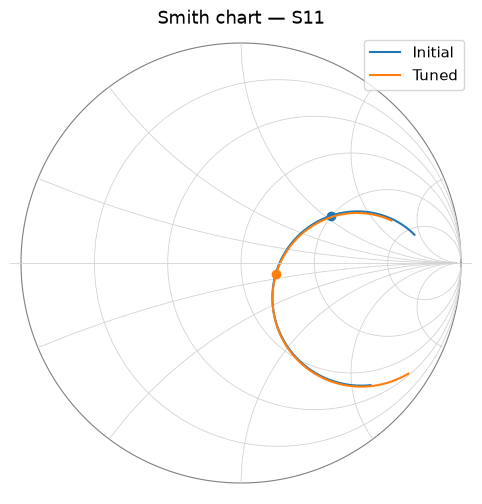

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
angle = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(angle), np.sin(angle), color='gray', linewidth=0.8)
reactance = np.linspace(-100, 100, 4000)
for resistance in [0.2, 0.5, 1, 2, 5]:
    z = resistance + 1j * reactance
    gamma = (z - 1) / (z + 1)
    ax.plot(gamma.real, gamma.imag, color='lightgray', linewidth=0.6)
for x in [-5, -2, -1, -0.5, -0.2, 0.2, 0.5, 1, 2, 5]:
    z = np.linspace(0, 100, 1000) + 1j * x
    gamma = (z - 1) / (z + 1)
    ax.plot(gamma.real, gamma.imag, color='lightgray', linewidth=0.6)
for name, label in [('ideal', 'Initial'), ('tuned', 'Tuned')]:
    data = np.loadtxt(f's11_smith_chart_dipole_{name}.csv', delimiter=',', skiprows=1, dtype=str)
    frequency = data[:, 0].astype(float)
    gamma = np.array([complex(value.replace(' ', '').replace('i', 'j')) for value in data[:, 1]])
    line, = ax.plot(gamma.real, gamma.imag, label=label)
    target = np.argmin(abs(frequency - 2.4))
    ax.plot(gamma[target].real, gamma[target].imag, 'o', color=line.get_color())
ax.axhline(0, color='lightgray', linewidth=0.6)
ax.set(aspect='equal', xlim=(-1.05, 1.05), ylim=(-1.05, 1.05), title='Smith chart — S11')
ax.axis('off')
ax.legend()
plt.show()

Finally, comparing the gain patterns at 2.4 GHz, we keep the dipole shape after tuning.

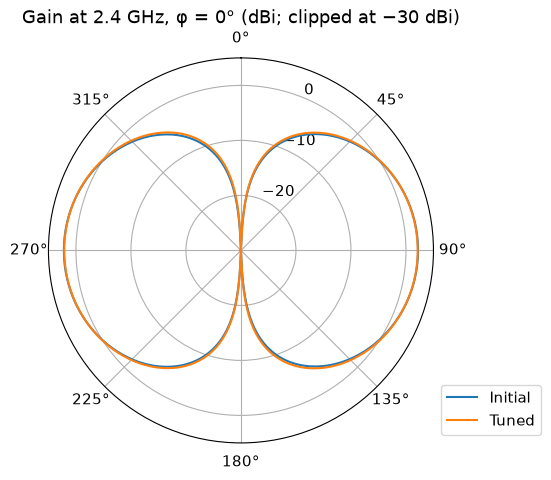

In [7]:
fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={'projection': 'polar'})
for data, label in [(initial_gain, 'Initial'), (tuned_gain, 'Tuned')]:
    ax.plot(np.deg2rad(data[:, 2]), np.maximum(data[:, 3], -30), label=label)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_ylim(-30, 5)
ax.set_yticks([-30, -20, -10, 0])
ax.set_title('Gain at 2.4 GHz, φ = 0° (dBi; clipped at −30 dBi)', pad=25)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0))
plt.show()